<a href="https://colab.research.google.com/github/ekaratnida/Applied-machine-learning/blob/master/Week04-workshop-1/Naive%20Bayes%20Spam%20Email%20Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
spam_df=pd.read_csv('https://raw.githubusercontent.com/nikhilkr29/Email-Spam-Classifier-using-Naive-Bayes/refs/heads/main/emails.csv')

In [3]:
spam_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [4]:
spam_df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [5]:
spam_df.tail()

,text,spam
5723,Subject: re : research and development charges...,0
5724,"Subject: re : receipts from visit jim , than...",0
5725,Subject: re : enron case study update wow ! a...,0
5726,"Subject: re : interest david , please , call...",0
5727,Subject: news : aurora 5 . 2 update aurora ve...,0


In [6]:
spam_df["spam"].value_counts()

,count
spam,
0,4360
1,1368


## Applying CountVectorizer to our Spam Ham Example

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, FeatureHasher
vectorizer = CountVectorizer() # Option: FeatureHasher(n_features=1000), TfidfVectorizer(), CountVectorizer()
dataVec = vectorizer.fit_transform(spam_df['text'])
dataVec.shape

(5728, 37303)

In [8]:
x = vectorizer.get_feature_names_out()
print(len(x))
x[37200:]

37303


array(['zimin', 'zimmerman', 'zimmy', 'zimno', 'zin', 'zinc', 'zingales',
       'zingalesuniversity', 'zip', 'zipcode', 'ziplink', 'ziplip',
       'zipmail', 'zipped', 'zipper', 'zipter', 'zisman', 'ziyong',
       'zkcc', 'zkhokher', 'zl', 'zlotowkach', 'zlotych', 'zlotys',
       'zlozyli', 'zlu', 'zmail', 'zmian', 'zmienilo', 'zmin', 'zmolek',
       'zmsx', 'zn', 'znac', 'znacza', 'znacznie', 'znajomych',
       'znakomitych', 'znalazlam', 'znalezc', 'znalezlismy', 'znam',
       'znana', 'zndnioays', 'znow', 'znowu', 'zobaczenie', 'zoch', 'zoe',
       'zofia', 'zoko', 'zoloftpain', 'zombie', 'zonal', 'zone', 'zones',
       'zongo', 'zonings', 'zonline', 'zoo', 'zoolant', 'zoraidaguerra',
       'zorganizowalem', 'zosta', 'zostal', 'zou', 'zrobic', 'zrobilem',
       'zt', 'ztvwo', 'zu', 'zucha', 'zuerich', 'zufferli', 'zuid',
       'zulie', 'zulkifli', 'zum', 'zuma', 'zunaechst', 'zunf',
       'zungenakrobatik', 'zur', 'zurich', 'zusaetzlich', 'zustellstatus',
       'zuyw',

In [9]:
print(dataVec)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 708380 stored elements and shape (5728, 37303)>
  Coords	Values
  (0, 32371)	1
  (0, 23381)	1
  (0, 18838)	1
  (0, 37024)	7
  (0, 10045)	1
  (0, 17688)	1
  (0, 21148)	1
  (0, 18848)	3
  (0, 28018)	1
  (0, 16655)	1
  (0, 33798)	4
  (0, 28142)	1
  (0, 9281)	3
  (0, 33450)	5
  (0, 21665)	2
  (0, 15415)	1
  (0, 24274)	4
  (0, 32635)	1
  (0, 4836)	5
  (0, 18234)	1
  (0, 18885)	1
  (0, 7546)	2
  (0, 16072)	2
  (0, 8043)	1
  (0, 20960)	3
  :	:
  (5727, 24851)	2
  (5727, 21635)	1
  (5727, 5715)	9
  (5727, 30968)	1
  (5727, 2807)	3
  (5727, 13324)	1
  (5727, 13113)	1
  (5727, 17380)	1
  (5727, 14115)	1
  (5727, 20276)	1
  (5727, 31860)	1
  (5727, 13114)	1
  (5727, 20470)	1
  (5727, 35337)	1
  (5727, 8614)	1
  (5727, 30116)	1
  (5727, 13507)	5
  (5727, 36243)	1
  (5727, 943)	2
  (5727, 2776)	1
  (5727, 30316)	1
  (5727, 17582)	1
  (5727, 33970)	1
  (5727, 10354)	1
  (5727, 11368)	1


In [10]:
max_value = dataVec.data.max()
print(f"The maximum value in dataVec is: {max_value}")

The maximum value in dataVec is: 596


In [11]:
maxVal = np.argmax(dataVec.data)
columnInx = dataVec.indices[maxVal]
featureName = vectorizer.get_feature_names_out()[columnInx]

print(f"The feature name associated with the maximum value (596) is: '{featureName}'")

The feature name associated with the maximum value (596) is: 'the'


## Dividing the Cell for Training and Testing Prior to Training

In [12]:
X=dataVec
y=spam_df['spam']

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y, random_state=123)

# 1. Gaussian NB

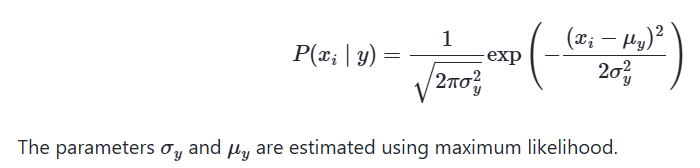

# 2. Multinomail NB

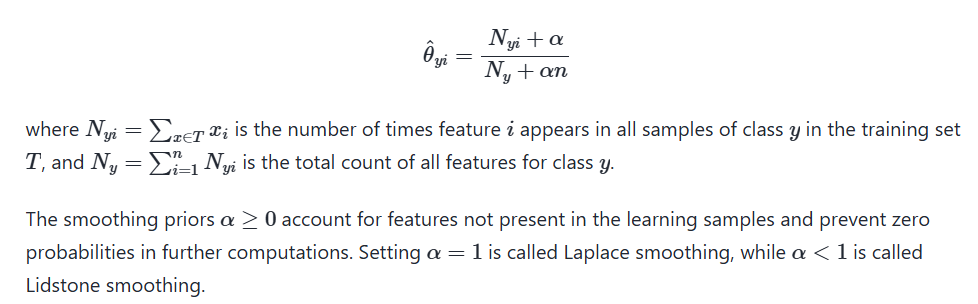

# 3. Bernoulli NB

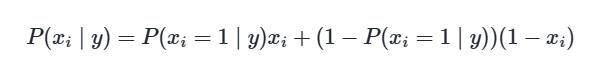

# 4. Categorical NB

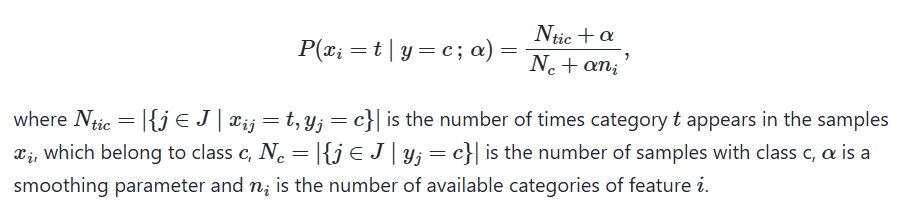

In [14]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB, GaussianNB, CategoricalNB

In [15]:
NB_classifier = MultinomialNB()
#NB_classifier = ComplementNB()
#NB_classifier = BernoulliNB()
#NB_classifier = GaussianNB()
#NB_classifier = CategoricalNB()

NB_classifier.fit(X_train,y_train)

MultinomialNB()

## Evaluating The Model

In [16]:
from sklearn.metrics import classification_report,confusion_matrix

In [17]:
y_predict_test=NB_classifier.predict(X_test)

In [18]:
cm=confusion_matrix(y_test,y_predict_test)
tn, fp, fn, tp = cm.ravel() #flat multi to 1D
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

True Negatives (TN): 861
False Positives (FP): 11
False Negatives (FN): 1
True Positives (TP): 273


In [19]:
print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       872
           1       0.96      1.00      0.98       274

    accuracy                           0.99      1146
   macro avg       0.98      0.99      0.99      1146
weighted avg       0.99      0.99      0.99      1146

